In [37]:
from copy import deepcopy
import h5py
import numpy as np
import scipy as sp
from scipy.sparse.linalg import norm
import matplotlib.pyplot as plt
import openfermion as of
from openfermionpyscf import run_pyscf
import qiskit
from quimb_tebd import (
    pauli_sum_to_mpo, get_drmg_ground_state, trotter_circuit_from_psum,
    energy_vs_d, get_evolved_states, fill_subspace_matrices_mps,
    exact_evolved_states, mps_to_vector, fill_subspace_matrices_vectors
)


In [ ]:
molec = "LiH"
basis = "sto-3g"
n_elec = 4
geometry = of.chem.geometry_from_pubchem(molec)
multiplicity = 1
dmrg_max_bond = [15, 16, 17]
tebd_max_bond = deepcopy(dmrg_max_bond)
mpo_max_bond = 500
steps = 10
eps = 1e-12
d = 20

In [39]:
# Get the Hamiltonian.
molecule = of.chem.MolecularData(
    geometry, basis, multiplicity
)
molecule = run_pyscf(molecule, run_scf=1, run_fci=1)
print(f"HF energy:", molecule.hf_energy)
print(f"FCI energy:", molecule.fci_energy)
hamiltonian = molecule.get_molecular_hamiltonian()
hamiltonian_qubop = of.transforms.jordan_wigner(hamiltonian)
hamiltonian_psum = of.transforms.qubit_operator_to_pauli_sum(hamiltonian_qubop)
ham_sparse = of.linalg.get_sparse_operator(hamiltonian_qubop)
qs = hamiltonian_psum.qubits
hamiltonian_mpo = pauli_sum_to_mpo(hamiltonian_psum, qs, mpo_max_bond)


HF energy: -7.767362135748557
FCI energy: -7.784460280031223


In [40]:
ham_norm = norm(ham_sparse)
tau = 10. * np.pi / ham_norm
print(f"tau = {tau:4.5e}")

tau = 1.12750e-01


In [41]:
# Run DMRG
ground_states = []
dmrg_energies = []
for i, chi_dmrg in enumerate(dmrg_max_bond):
    ground_state, energy, number = get_drmg_ground_state(hamiltonian_mpo, n_elec, chi_dmrg)
    ground_states.append(ground_state.copy())
    dmrg_energies.append(energy)
    print(f"DMRG ground state has energy {energy} and occupation {number}.")

DMRG ground state has energy -7.618577175876827 and occupation 4.000000186108945.
DMRG ground state has energy -7.78444923260747 and occupation 3.9999999882801216.
DMRG ground state has energy -7.7844483450415805 and occupation 4.000000014397578.


In [61]:
# Do TEBD Krylov with the DMRG reference state.
ev_circuit = trotter_circuit_from_psum(hamiltonian_psum, tau, steps)
ev_circuit_transpiled = qiskit.transpile(ev_circuit, basis_gates=["u3", "cx"])
tebd_energies = np.zeros((len(tebd_max_bond), d-1), dtype=float)
tebd_all_h = np.zeros((len(tebd_max_bond), d, d), dtype=complex)
tebd_all_s = np.zeros((len(tebd_max_bond), d, d), dtype=complex)
bond_sizes = np.zeros((len(tebd_max_bond), d, len(hamiltonian_mpo.tensors)-1), dtype=int)
tebd_num_kept = np.zeros((len(tebd_max_bond), d-1), dtype=int)
for i, chi_tebd in enumerate(tebd_max_bond):
    print(f"chi_tebd = {chi_tebd}")
    states = get_evolved_states(ev_circuit_transpiled, ground_states[0].copy(), d, chi_tebd, None)
    for j, state in enumerate(states):
        bond_sizes[i, j, :] = state.bond_sizes()
    h, s = fill_subspace_matrices_mps(states, hamiltonian_mpo)
    energies, num_kept = energy_vs_d(h, s, method="threshold", eps=eps)
    tebd_energies[i, :] = energies
    tebd_all_h[i, :, :] = h
    tebd_all_s[i, :, :] = s
    tebd_num_kept[i, :] = num_kept


chi_tebd = 15
chi_tebd = 16
chi_tebd = 17


In [66]:
# Use the unitary of the evolution circuit.
ref_vector = mps_to_vector(ground_states[0])
states = exact_evolved_states(ev_circuit_transpiled, ref_vector, d)
h, s = fill_subspace_matrices_vectors(states, ham_sparse)
energies_u, num_kept_u = energy_vs_d(h, s, method="threshold", eps=eps)

sorted_inds = ['k0', 'k1', 'k2', 'k3', 'k4', 'k5', 'k6', 'k7', 'k8', 'k9', 'k10', 'k11']


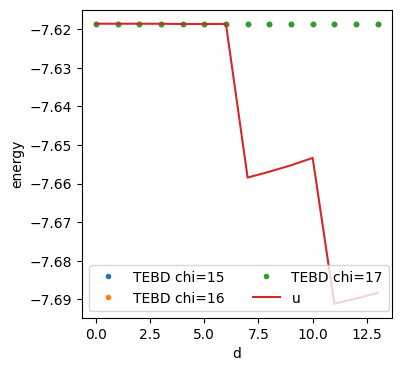

In [67]:
fig2, ax2 = plt.subplots(1, 1, figsize=(4, 4))
dmrg_colors = ["green", "blue", "yellow"]
# for i, (chi, dmrg_energy) in enumerate(zip(dmrg_max_bond, dmrg_energies)):
#     ax2.hlines(dmrg_energy, 0., tebd_energies.shape[1], dmrg_colors[i], label=f"DMRG chi={chi}")
# ax2.hlines(molecule.hf_energy, 0., tebd_energies.shape[1], linestyle="--", colors=["brown"], label="HF")
# ax2.hlines(molecule.fci_energy, 0., tebd_energies.shape[1], linestyle="--", colors=["black"], label="FCI")
for i, chi in enumerate(tebd_max_bond):
    ax2.plot(tebd_energies[i, :], '.', label=f"TEBD chi={chi}")
ax2.plot(energies_u, label="u")
ax2.set_ylabel("energy")
ax2.set_xlabel("d")
ax2.legend(ncols=2)

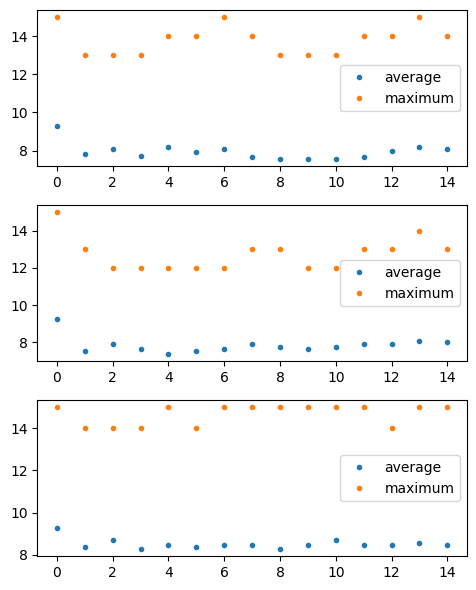

In [63]:
fig3, ax3 = plt.subplots(len(dmrg_max_bond), 1, figsize=(5, 6))
for i, chi_tebd in enumerate(tebd_max_bond):
    chi_avg = np.average(bond_sizes[i, :, :], axis=1)
    chi_max = np.max(bond_sizes[i, :, :], axis=1)
    ax3[i].plot(chi_avg, '.', label="average")
    ax3[i].plot(chi_max, '.', label="maximum")
    ax3[i].legend()
fig3.tight_layout()

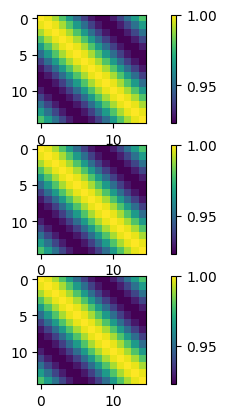

In [64]:
fig4, ax4 = plt.subplots(len(tebd_max_bond), 1)
for i, chi_tebd in enumerate(tebd_max_bond):
    im = ax4[i].imshow(np.abs(tebd_all_s[i, :, :]))
    fig4.colorbar(im)

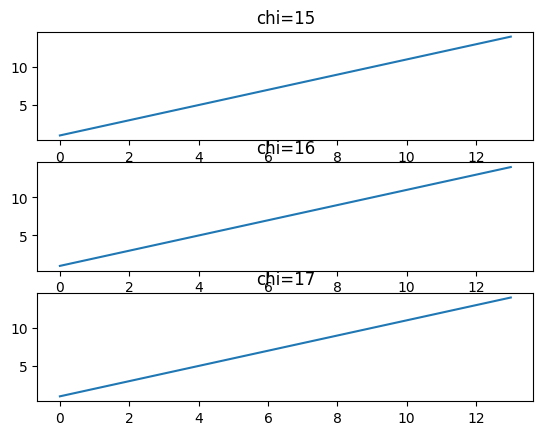

In [65]:
fig5, ax5 = plt.subplots(len(tebd_max_bond))
for i, chi_tebd in enumerate(tebd_max_bond):
    ax5[i].plot(tebd_num_kept[i, :])
    ax5[i].set_title(f"chi={chi_tebd}")